# EEG Coding Brain Preprocessing Script


## Packages needed


In [661]:
 # pip install mne 
 # pip install pandas
 # pip install -U autoreject
 # pip install mne-icalabel
 # pip intall torch


SyntaxError: invalid syntax (3222999088.py, line 6)

In [1]:
###IMPORT PACKAGES
import os
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import re 
from autoreject import AutoReject
from autoreject import Ransac
from autoreject import get_rejection_threshold
from mne.preprocessing import read_ica
from mne.preprocessing import ICA  # Ensure ICA is imported
from mne import read_epochs
from mne_icalabel import label_components
from mne_bids import BIDSPath, write_raw_bids
from mne_bids import write_raw_bids, BIDSPath



# Preprocessing
## Read in participant BDF files


# EEG Coding Brain Preprocessing Script


## Packages needed


# Preprocessing
## Read in participant BDF files


In [2]:
# Set the base project path
project_path = '/Users/jasongeller/Desktop/EEG_Codin/'

# Define paths to each folder directly using the project path
raw_data_path = project_path + 'raw_data/'
raw_files_path = project_path + 'raw_files/'
epochs_uncleaned_path = project_path + 'uncleaned_epochs/'
ica_path = project_path + 'ICA_epochs/'
ica_figs_path = project_path + 'ICA_figs/'
ica_labels_path = project_path + 'ICA_label/'
ica_cleaned_path = project_path + 'ICA_clean/'
baseline_corrected_path = project_path + 'baseline_correct_epochs/'
ar_epochs_path = project_path + 'autoreject_epochs/'
evoked_path = project_path + 'Evokeds/'
grand_path = project_path + 'Grand_average/'
bids_path = project_path + 'bids_dataset/'

# Now, you can use these paths to read or save files



Let's get subject names

In [4]:

subs = [f.replace('.bdf', '') for f in os.listdir(raw_data_path) if f.endswith('.bdf')]

subs

['1018-GZN0K',
 '1016-U5RMG',
 '1030-HBQT4',
 '1017-ua5ro',
 '1029-N6INB',
 '1009-QKXGY',
 '1007-0I5L2']

In [20]:
# bad channels by Partcpnats
bad_channels_dict = dict()
bad_channels_dict[subs[0]]= []
bad_channels_dict[subs[1]]= []
bad_channels_dict[subs[2]]= []
bad_channels_dict[subs[3]]= []
bad_channels_dict[subs[4]]= []
bad_channels_dict[subs[5]]= ['T7', 'PO7', 'O1', 'F4', 'F8', "FC6"]
bad_channels_dict[subs[6]]= []

# just add more

In [ ]:
### Define Modular Functions for Each Processing Step

## Bad Channels


Make sure dict corresponds to the order in subs. 

In [19]:
subs

['1018-GZN0K',
 '1016-U5RMG',
 '1030-HBQT4',
 '1017-ua5ro',
 '1029-N6INB',
 '1009-QKXGY',
 '1007-0I5L2']

In [ ]:
# bad channels by Partcpnats
bad_channels_dict = dict()
bad_channels_dict[subs[0]]= []
bad_channels_dict[subs[1]]= []
bad_channels_dict[subs[2]]= []
bad_channels_dict[subs[3]]= []
bad_channels_dict[subs[4]]= []
bad_channels_dict[subs[5]]= ['T7', 'PO7', 'O1', 'F4', 'F8', "FC6"]
bad_channels_dict[subs[6]]= []

# just add more

If there are bad channels make sure to note them so they can be excluded. 

# Raw Data Processing

This function, load_and_process_raw, is designed to load, preprocess, and save raw EEG data in BioSemi BDF format for a given subject. It begins by checking if the raw BDF file exists and loads it while excluding the external EXG channels. The raw data is then filtered between 1 Hz and 100 Hz to prepare it for artifact rejection and ICA. The function sets a standard 64-channel BioSemi montage and re-references the EEG signals to the mastoid electrodes (T7 and T8). Any known bad channels for the subject are marked, and the data is resampled to 200 Hz to reduce file size and improve efficiency.

Next, the function detects stimulus events and reclassifies them into “congruent” or “incongruent” categories based on predefined event codes and corresponding correct responses within a 20-second window. These reclassified events are converted into annotations and added to the raw data for easy access in later analyses. Finally, the processed data, including the annotations, is saved as a .fif file, replacing any existing file if overwrite=True. This function provides a complete pipeline for loading, processing, and saving raw EEG data with event annotations embedded for subsequent analysis.

In [551]:
def load_and_process_raw(subject, raw_path, file_path, overwrite=True, save_events_as_annotations=True):
    # Check if the BDF file exists
    raw_filename = file_path + subject + ".bdf"
    if not os.path.exists(raw_filename):
        raise FileNotFoundError(f"File {raw_filename} not found.")

    # Define path for saving the raw file
    raw_save_path = raw_path + subject + '-raw.fif'
    events_save_path = raw_path + subject + '-events.fif'

    # Check if the raw file already exists; if it does, skip processing unless overwrite is True
    if os.path.exists(raw_save_path) and not overwrite:
        print(f"Skipping {subject}: raw file already exists.")
        return None

    # Load raw data with EXG channels excluded
    raw = mne.io.read_raw_bdf(raw_filename, preload=True, exclude=["EXG" + str(i) for i in range(1, 9)])

    # Filter the data for ICA high pass
    raw_filtered = raw.filter(l_freq=1.0, h_freq=100.0)

    # Set montage
    montage = mne.channels.make_standard_montage('biosemi64')
    raw_filtered.set_montage(montage)
    
    # Set EEG reference (to mastoids)
    raw_filtered.set_eeg_reference(["T7", "T8"])
    
    # Set bad channels (from a dictionary or predefined list)
    bad_channels = bad_channels_dict[subject] 
    raw_filtered.info['bads'] = bad_channels

    raw_filtered.resample(200)  # Resample data first


    # Find events in the raw data
    events = mne.find_events(raw_filtered)

    # Event codes and dictionary
    event_dict = {
        "conincon2": 32, "conincon3": 33, "conincon4": 34,
        "coninincon2": 42, "coninincon3": 43, "coninincon4": 44,
        "inconinincon2": 52, "inconinincon3": 53, "inconinincon4": 54,
        "correct": 100, "incorr": 101
    }
    congruent_codes = [32, 33, 34]
    incongruent_codes = [52, 53, 54]
    correct_code = 100

    # Extended time window
    time_window = 20000  # 20 seconds
    sample_window = int((time_window / 1000) * raw_filtered.info['sfreq'])

    # Filter events and reclassify them
    filtered_events = []
    for i, event in enumerate(events):
        if event[2] in congruent_codes or event[2] in incongruent_codes:
            for j in range(i + 1, len(events)):
                if events[j, 0] - event[0] > sample_window:
                    break
                if events[j, 2] == correct_code:
                    new_code = 200 if event[2] in congruent_codes else 201
                    filtered_events.append([event[0], event[1], new_code])
                    break

    filtered_events = np.array(filtered_events)

    # New event dictionary for reclassified events
    new_event_dict = {
        "congruent": 200,
        "incongruent": 201,
    }

    event_desc = {200: 'congruent', 201: 'incongruent'}

    annotations = mne.annotations_from_events(filtered_events, event_desc=event_desc,
                                                  sfreq=raw_filtered.info['sfreq'], orig_time=raw_filtered.info['meas_date'])
    raw_filtered.set_annotations(annotations)
    
    print("Events converted to annotations and added to raw data.")

    # Save the raw data to the specified path
    if overwrite:
        if os.path.exists(raw_save_path):
            os.remove(raw_save_path)
    
    raw_filtered.save(raw_save_path, overwrite=True)
    print(f"Saved raw data for {subject} at {raw_save_path}")

    return raw_filtered

In [ ]:
raw = [
    load_and_process_raw(
        subject,  
        file_path=raw_data, 
        raw_path=raw_files, 
        overwrite=True
    ) 
    for subject in subs
]

# BIDS

In [66]:

import mne
from mne_bids import write_raw_bids, BIDSPath

# MNE-BIDS: Write data to BIDS format
def write_to_bids(subject, file_path, bids_root, overwrite=True):
    """
    Write raw EEG data to BIDS format, including events and event dictionary.
    
    Parameters:
    - subject: str
        The subject identifier (e.g., '1018-GZN0K').
    - file_path: pathlib.Path
        The path to the directory where the raw .bdf files are located.
    - bids_root: pathlib.Path
        The root directory where the BIDS dataset should be saved.
    - overwrite: bool
        Whether to overwrite existing files in the BIDS dataset (default is True).
    """
    
    # Define raw filename (assuming file is in the format "subject.bdf")
    raw_filename = file_path + (subject + ".bdf")

    # Load raw .bdf data
    raw = mne.io.read_raw_bdf(raw_filename)

    # Find events in the raw data (from the stimulus channel)
    events = mne.find_events(raw)

    # Define event codes and dictionary
    event_dict = {
        "conincon2": 32, "conincon3": 33, "conincon4": 34,
        "coninincon2": 42, "coninincon3": 43, "coninincon4": 44,
        "inconinincon2": 52, "inconinincon3": 53, "inconinincon4": 54,
        "correct": 100, "incorr": 101
    }

    # Remove hyphen from the subject ID
    new_subject = subject.replace("-", "")

    # Create BIDS path for saving (modify task/session as needed)
    bids_path = BIDSPath(
        subject=new_subject,
        session='01',
        task='congincongcodingbrain',
        root=bids_root,
        datatype='eeg'
    )

    # Write the raw data to BIDS format
    write_raw_bids(
        raw,
        bids_path=bids_path,
        overwrite=overwrite
    )

    # Add events to the BIDS dataset
    event_tsv_filename = bids_path.directory / f"{bids_path.basename}_events.tsv"
    mne.write_events(event_tsv_filename, events)

    print(f"BIDS data saved for subject {new_subject} at {bids_path.directory}")

In [67]:
[write_to_bids(subject, file_path=raw_data_path,bids_root=bids_path, overwrite=True) for subject in subs]

Extracting EDF parameters from /Users/jasongeller/Desktop/EEG_Codin/raw_data/1018-GZN0K.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Trigger channel Status has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
579 events found on stim channel Status
Event IDs: [ 32  33  34  42  43  44  52  53  54 100 101]
Extracting EDF parameters from /Users/jasongeller/Desktop/EEG_Codin/raw_data/1018-GZN0K.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/participants.tsv'...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/participants.json'...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/dataset_description.json'...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-1018GZN0K/ses-01/eeg/sub-1018GZN0K_ses-01_task-congi

/var/folders/b6/cndg9nj53jnfy45qtx6h533r0000gs/T/ipykernel_2468/928284522.py:50: RuntimeWarning: No events found or provided. Please add annotations to the raw data, or provide the events and event_id parameters. For resting state data, BIDS recommends naming the task using labels beginning with "rest".
  write_raw_bids(


Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-1018GZN0K/ses-01/sub-1018GZN0K_ses-01_scans.tsv'...
Wrote /Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-1018GZN0K/ses-01/sub-1018GZN0K_ses-01_scans.tsv entry with eeg/sub-1018GZN0K_ses-01_task-congincongcodingbrain_eeg.bdf.
BIDS data saved for subject 1018GZN0K at /Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-1018GZN0K/ses-01/eeg
Extracting EDF parameters from /Users/jasongeller/Desktop/EEG_Codin/raw_data/1016-U5RMG.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...


/var/folders/b6/cndg9nj53jnfy45qtx6h533r0000gs/T/ipykernel_2468/928284522.py:58: RuntimeWarning: This filename (/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-1018GZN0K/ses-01/eeg/sub-1018GZN0K_ses-01_task-congincongcodingbrain_events.tsv) does not conform to MNE naming conventions. All events files should end with .eve, -eve.fif, -eve.fif.gz, -eve.lst, -eve.txt, _eve.fif, _eve.fif.gz, _eve.lst or _eve.txt
  mne.write_events(event_tsv_filename, events)


Trigger channel Status has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
579 events found on stim channel Status
Event IDs: [ 32  33  34  42  43  44  52  53  54 100]
Extracting EDF parameters from /Users/jasongeller/Desktop/EEG_Codin/raw_data/1016-U5RMG.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/participants.tsv'...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/participants.json'...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/dataset_description.json'...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-1016U5RMG/ses-01/eeg/sub-1016U5RMG_ses-01_task-congincongcodingbrain_eeg.json'...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-1016U5RMG/ses-01/eeg/sub-1016U5RMG_ses-01_task-congincongcodingbrain_channels.tsv'...
Cop

...

Trigger channel Status has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
579 events found on stim channel Status
Event IDs: [ 32  33  34  42  43  44  52  53  54 100 101 162]
Extracting EDF parameters from /Users/jasongeller/Desktop/EEG_Codin/raw_data/1007-0I5L2.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/participants.tsv'...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/participants.json'...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/dataset_description.json'...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-10070I5L2/ses-01/eeg/sub-10070I5L2_ses-01_task-congincongcodingbrain_eeg.json'...
Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-10070I5L2/ses-01/eeg/sub-10070I5L2_ses-01_task-congincongcodingbrain_channels.tsv

/var/folders/b6/cndg9nj53jnfy45qtx6h533r0000gs/T/ipykernel_2468/928284522.py:50: RuntimeWarning: No events found or provided. Please add annotations to the raw data, or provide the events and event_id parameters. For resting state data, BIDS recommends naming the task using labels beginning with "rest".
  write_raw_bids(


Writing '/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-10070I5L2/ses-01/sub-10070I5L2_ses-01_scans.tsv'...
Wrote /Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-10070I5L2/ses-01/sub-10070I5L2_ses-01_scans.tsv entry with eeg/sub-10070I5L2_ses-01_task-congincongcodingbrain_eeg.bdf.
BIDS data saved for subject 10070I5L2 at /Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-10070I5L2/ses-01/eeg


/var/folders/b6/cndg9nj53jnfy45qtx6h533r0000gs/T/ipykernel_2468/928284522.py:58: RuntimeWarning: This filename (/Users/jasongeller/Desktop/EEG_Codin/bids_dataset/sub-10070I5L2/ses-01/eeg/sub-10070I5L2_ses-01_task-congincongcodingbrain_events.tsv) does not conform to MNE naming conventions. All events files should end with .eve, -eve.fif, -eve.fif.gz, -eve.lst, -eve.txt, _eve.fif, _eve.fif.gz, _eve.lst or _eve.txt
  mne.write_events(event_tsv_filename, events)


[None, None, None, None, None, None, None]

# ICA Raw

The run_ica function is designed to perform Independent Component Analysis (ICA) on raw EEG data for a specified subject, using the chosen ICA method and saving the computed ICA solution. The function starts by defining the file paths for the raw EEG data and where the ICA solution will be saved. If an ICA file for the subject already exists and overwriting is not permitted, the function will skip the computation and return early.

It then checks whether the raw EEG data file exists. If not, it raises a FileNotFoundError. If the file exists, the raw data is loaded into memory. The function initializes the ICA object with 15 components, using the specified ICA method (defaulting to ‘infomax’) and sets extended=True for the extended infomax method. The ICA is then fitted to the raw EEG data, decomposing it into independent components that can later be used to identify and remove artifacts such as eye movements or muscle activity.

Finally, the computed ICA solution is saved to a file, and the function prints a message indicating the location of the saved ICA solution. This function is useful for preparing raw EEG data for artifact rejection using ICA, saving the resulting decomposition for future analysis.

In [510]:
def run_ica(subject, raw_path, save_ica,  overwrite=False, method='infomax'):
    """
    Run ICA on the provided subject's raw data using specified ICA method, applying rejection thresholds and saving the ICA solution.
    
    Parameters:
    subject (str): Subject identifier.
    epoch_path (str): Path to the folder containing the epoch file.
    save_ica (str): Path to save the ICA file.
    overwrite (bool): If True, overwrite the existing ICA file. Default is True.
    method (str): ICA method to use ('fastica', 'infomax', 'extended-infomax'). Default is 'extended-infomax'.
    
    Returns:
    ICA: The fitted ICA object if processing is done, otherwise None.
    """
    
    # Define file paths
    raw_file_path = os.path.join(raw_path, f"{subject}-raw.fif")
    ica_file_path = os.path.join(save_ica, f"{subject}-ica.fif")
    
    # Check if the ICA file already exists and skip if overwrite is False
    if os.path.exists(ica_file_path) and not overwrite:
        print(f"ICA file already exists for {subject}. Skipping ICA computation.")
        return None  # Early exit if file exists and overwrite is False
    
    # Load the epochs file
    if not os.path.exists(raw_file_path):
        raise FileNotFoundError(f"raw file for {subject} not found at {raw_file_path}.")
    
    raw = mne.io.read_raw_fif(raw_file_path, preload=True)
    
    # Initialize and fit ICA using the specified method
    ica = ICA(
    n_components=15,
    max_iter="auto",
    method="infomax",
    random_state=97,
    fit_params=dict(extended=True)
)
    ica.fit(raw)
    
    # Save the ICA solution
    ica.save(ica_file_path, overwrite=overwrite)  # Pass overwrite to ica.save()
    print(f"ICA solution saved for {subject} at {ica_file_path}.")
    
    return ica

In [511]:
# Process each subject
for subject in subs:
    print(f"Running ICA for subject {subject}")
    run_ica(subject=subject, raw_path=raw_files, save_ica=ica_files, overwrite=True)

Running ICA for subject 1018-GZN0K
Opening raw data file /Users/jasongeller/Desktop/EEG_Codin/raw_files/1018-GZN0K-raw.fif...
    Range : 0 ... 425999 =      0.000 ...  2129.995 secs
Ready.
Reading 0 ... 425999  =      0.000 ...  2129.995 secs...
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 15 components
Computing Extended Infomax ICA
Fitting ICA took 26.6s.
Overwriting existing file.
Writing ICA solution to /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1018-GZN0K-ica.fif...
ICA solution saved for 1018-GZN0K at /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1018-GZN0K-ica.fif.
Running ICA for subject 1016-U5RMG
Opening raw data file /Users/jasongeller/Desktop/EEG_Codin/raw_files/1016-U5RMG-raw.fif...
    Range : 0 ... 393999 =      0.000 ...  1969.995 secs
Ready.
Reading 0 ... 393999  =      0.000 ...  1969.995 secs...
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 15 comp

# ICA Cleaning

## Plot ICA components

In [512]:

def plot_ica(subject, ica_path, save_plots, ica_plot_path):
    """
    Plots ICA components and saves each figure if specified.
    
    Parameters:
    subject (str): Subject identifier.
    ica_path (str): Path to load the ICA file.
    save_plots (bool): If True, saves the plot of ICA components.
    ica_plot_path (str): Path to save the ICA component plots.
    """
    
    # Load ICA solutions from file
    ica = read_ica(os.path.join(ica_path, subject + "-ica.fif"))
    
    # Plot ICA components
    ica_figures = ica.plot_components()
    
    if save_plots:
        if isinstance(ica_figures, list):  # Case when multiple figures are returned
            for i, fig in enumerate(ica_figures):
                save_path = os.path.join(ica_plot_path, f"{subject}_ica_components_page_{i+1}.pdf")
                fig.savefig(save_path, dpi=600)
                print(f"Figure {i+1} for subject {subject} saved at {save_path}")
        else:  # Case when a single figure is returned
            save_path = os.path.join(ica_plot_path, f"{subject}_ica_components.pdf")
            ica_figures.savefig(save_path, dpi=600)
            print(f"Figure for subject {subject} saved at {save_path}")
    else:
        print('Not saving plots; set "save_plots" to "True" to save')



Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1018-GZN0K-ica.fif ...
Now restoring ICA solution ...
Ready.


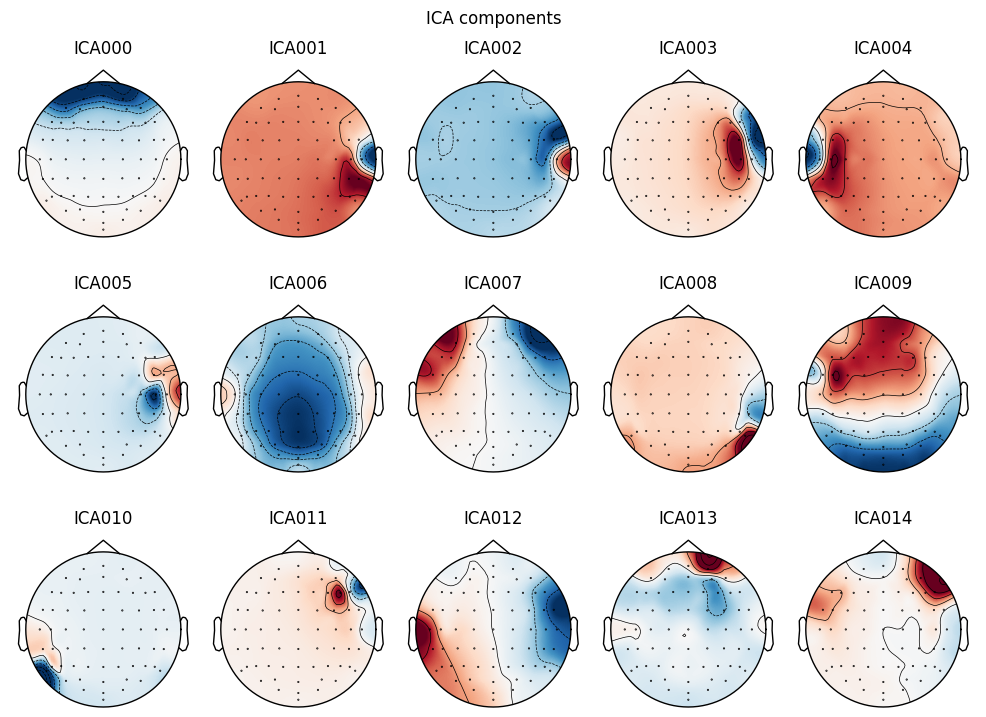

Figure for subject 1018-GZN0K saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_figs/1018-GZN0K_ica_components.pdf
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1016-U5RMG-ica.fif ...
Now restoring ICA solution ...
Ready.


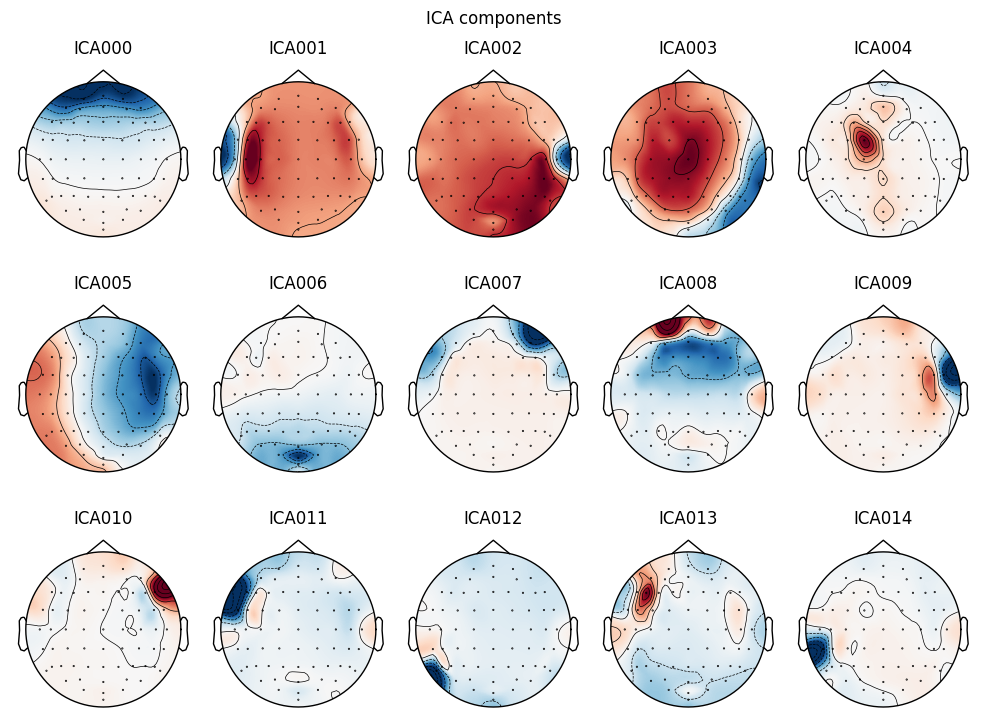

Figure for subject 1016-U5RMG saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_figs/1016-U5RMG_ica_components.pdf
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1030-HBQT4-ica.fif ...
Now restoring ICA solution ...
Ready.


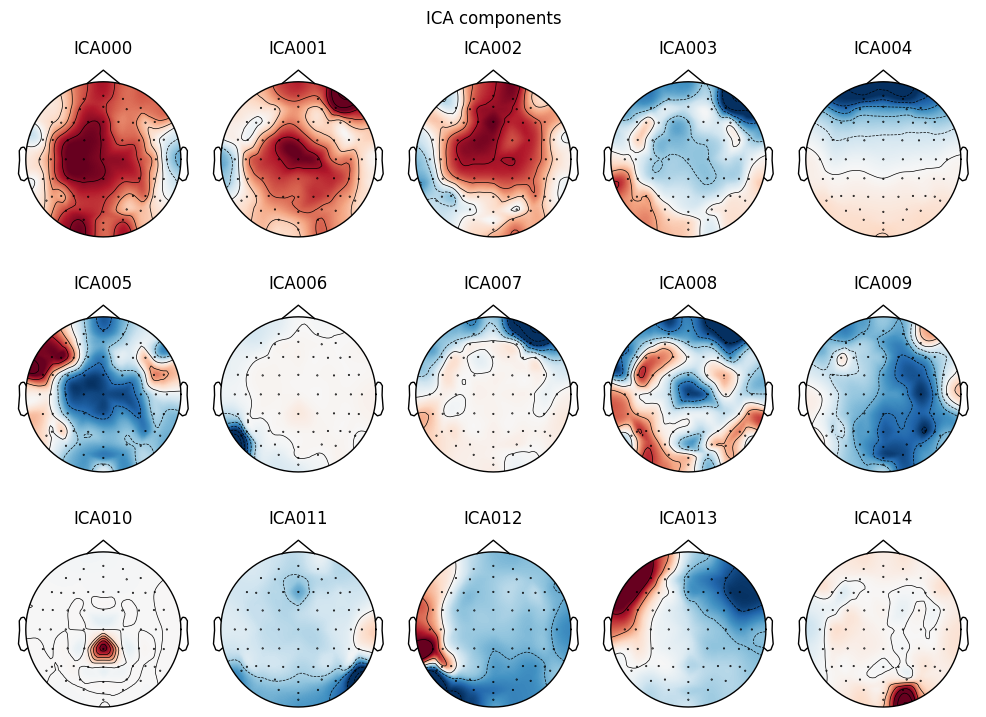

Figure for subject 1030-HBQT4 saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_figs/1030-HBQT4_ica_components.pdf
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1017-ua5ro-ica.fif ...
Now restoring ICA solution ...
Ready.


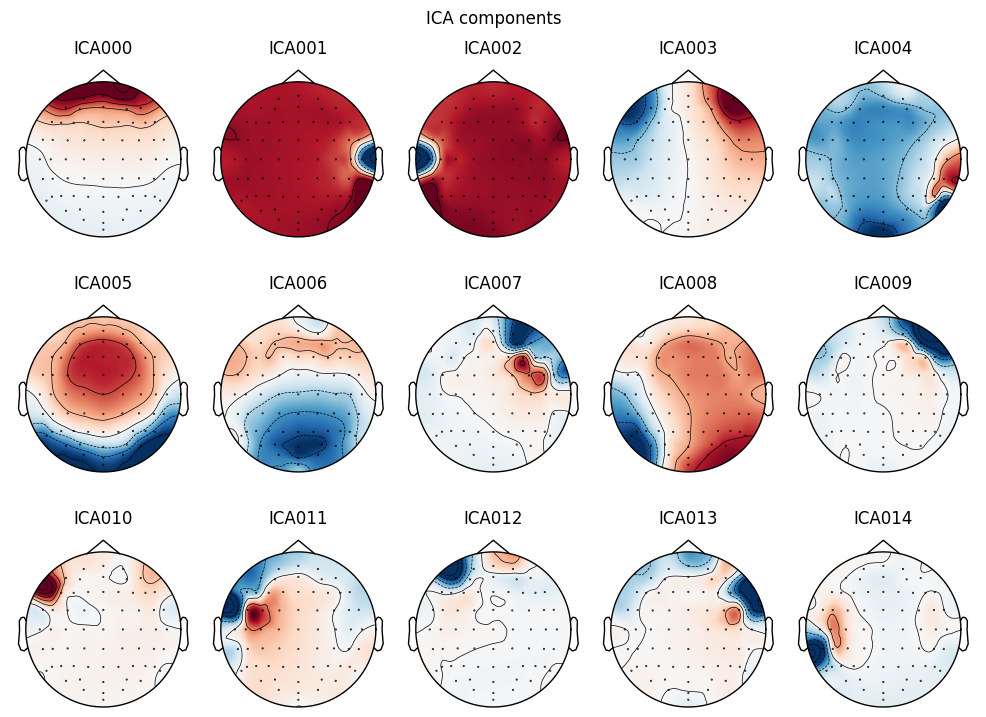

Figure for subject 1017-ua5ro saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_figs/1017-ua5ro_ica_components.pdf
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1029-N6INB-ica.fif ...
Now restoring ICA solution ...
Ready.


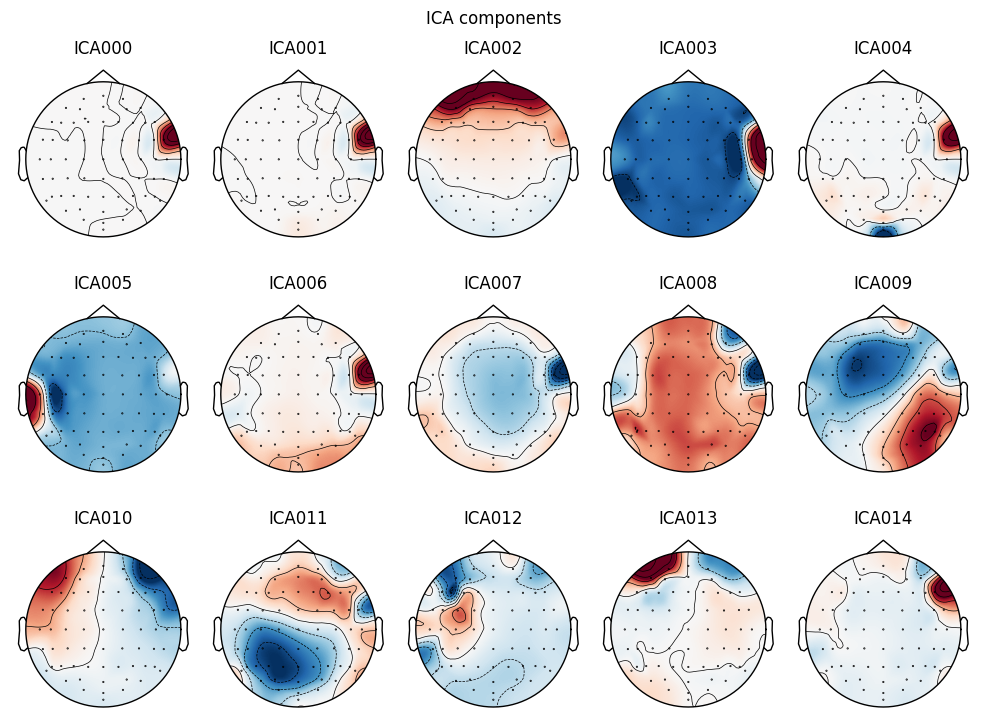

Figure for subject 1029-N6INB saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_figs/1029-N6INB_ica_components.pdf
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1009-QKXGY-ica.fif ...
Now restoring ICA solution ...
Ready.


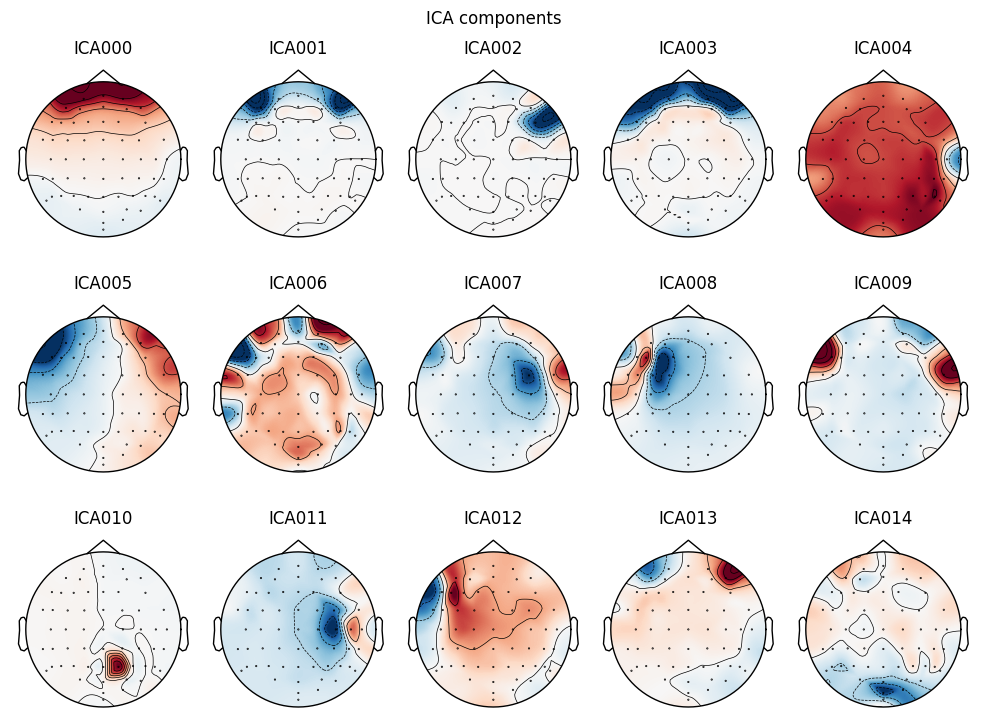

Figure for subject 1009-QKXGY saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_figs/1009-QKXGY_ica_components.pdf
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1007-0I5L2-ica.fif ...
Now restoring ICA solution ...
Ready.


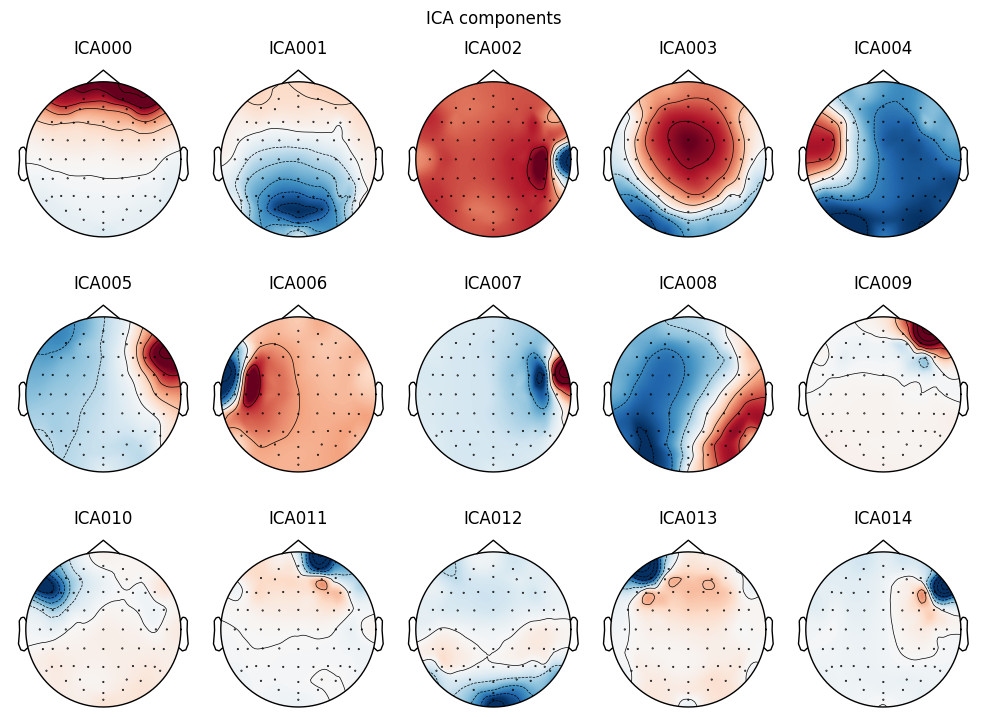

Figure for subject 1007-0I5L2 saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_figs/1007-0I5L2_ica_components.pdf


In [513]:
# Example usage for multiple subjects
for subject in subs: 
    plot_ica(subject, ica_path=ica_files, save_plots=True, ica_plot_path=ica_figs)

## Label bad components

The classify_and_apply_ica function is responsible for cleaning EEG data by applying Independent Component Analysis (ICA) to remove artifacts such as eye movements or muscle activity. It begins by loading the raw EEG data and a precomputed ICA solution for a specified subject. Using ICLabel, the function classifies the ICA components into categories such as “brain,” “eye,” or “muscle.” Components labeled as non-brain, such as those associated with artifacts, are marked for exclusion. The function then applies the ICA solution to the raw data, removing the identified artifacts and leaving a cleaner EEG dataset. After applying ICA, the function filters the cleaned data and segments it into epochs around specific events. Finally, the cleaned epochs are saved in a designated path, providing a processed dataset free from common artifacts and ready for further analysis. If specified, the function also prints the labels and indices of the excluded components for inspection.

In [559]:

def classify_and_apply_ica(subject, raw_path, ica_path, ica_label_path, ica_cleaned_path,  print_labels=True):
    """
    Load epochs and ICA files, classify ICA components using ICLabel, save the labels as a CSV file,
    mark bad components for exclusion, apply ICA to clean the epochs, and save the cleaned epochs.
    
    Parameters:
    subject (str): Subject identifier.
    epochs_path (str): Directory path to load the epochs file.
    ica_path (str): Directory path to load the ICA file.
    save_path (str): Directory path to save the labels CSV file and cleaned epochs.
    print_labels (bool): If True, prints the classification labels and exclusion indices. Default is True.
    
    Returns:
    dict: Dictionary containing the classification results.
    list: List of indices of components to exclude.
    mne.Epochs: The cleaned epochs after applying ICA.
    """
    
    # Load epochs and ICA files
    raw_file = os.path.join(raw_path, f"{subject}-raw.fif")
    ica_file = os.path.join(ica_path, f"{subject}-ica.fif")
    
    if not os.path.exists(raw_file):
        raise FileNotFoundError(f"raw file for subject {subject} not found at {raw_file}.")
    if not os.path.exists(ica_file):
        raise FileNotFoundError(f"ICA file for subject {subject} not found at {ica_file}.")
    
    raw =  mne.io.read_raw_fif(raw_file, preload=True)


    ica = read_ica(ica_file)
    
    # Apply ICLabel to classify components

    #ica_channels = ica_channels_dict[subject]# in

    labels = label_components(raw, ica, method="iclabel")
    
   # Extract label names and identify indices to exclude
    labels = labels["labels"]
    exclude_idx = [
        idx for idx, label in enumerate(labels) if label not in ["brain", "other"]
    ]
    if print_labels:
        print(f"Excluding these ICA components: {exclude_idx}")
    
    # Mark bad components for exclusio       
     
    ica.exclude += exclude_idx
    
    # Apply the ICA solution to remove the bad components from epochs
    raw_clean = ica.apply(raw.copy())  # Apply ICA on a copy of the epochs
    
    raw_clean.filter(.1, 40, fir_design='firwin') #for ICA filter between 1

    epochs = mne.Epochs(raw_clean, tmin=-0.2, tmax=1, baseline=None, preload=True, reject=None)
    
    # Save the cleaned epochs
    cleaned_epochs_file = os.path.join(ica_cleaned_path, f"{subject}_clean-epo.fif")
    epochs.save(cleaned_epochs_file, overwrite=True)
    print(f"Cleaned epochs for subject {subject} saved at {cleaned_epochs_file}")
    
    # Convert labels dictionary to a DataFrame
   # label_data = []
  #  for idx, label in enumerate(labels):
   #     label_data.append({'Component': idx, 'Label': label})
    
   # labels_df = pd.DataFrame(label_data)
    
    # Save labels to CSV
   # csv_save_path = os.path.join(ica_label_path, f"{subject}_ica_labels.csv")
   # labels_df.to_csv(csv_save_path, index=False)
   # print(f"Labels for subject {subject} saved at {csv_save_path}")
    
    # Optional: Print labels for inspection
  #  if print_labels:
  #      print(labels)
    
    return epoch_clean


In [560]:
epoch_clean = [classify_and_apply_ica(subject, raw_path=raw_files, ica_path=ica_files, ica_label_path=ica_labels, ica_cleaned_path=ica_clean_epochs, print_labels=True) for subject in subs]

Opening raw data file /Users/jasongeller/Desktop/EEG_Codin/raw_files/1018-GZN0K-raw.fif...
    Range : 0 ... 425999 =      0.000 ...  2129.995 secs
Ready.
Reading 0 ... 425999  =      0.000 ...  2129.995 secs...
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1018-GZN0K-ica.fif ...
Now restoring ICA solution ...
Ready.
Excluding these ICA components: [0, 1, 2, 3, 5, 6, 7, 10, 11, 13, 14]
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 11 ICA components
    Projecting back using 64 PCA components
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Used Annotations descriptions: ['congruent', 'incongruent']
Not setting metadata
289 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 289 events and 241 original time points ...
0 bad epochs dropped
Overwriting existing file.
Overwriting existing file.
Cleaned epochs for subject 1018-GZN0K saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_clean/1018-GZN0K_clean-epo.fif
Opening raw data file /Users/jasongeller/Desktop/EEG_Codin/raw_files/1016-U5RMG-raw.fif...
    Range : 0 ... 393999 =      0.000 ...  1969.995 secs
Ready.
Reading 0 ... 393999  =      0.000 ...  1969.995 secs...
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1016-U5RMG-ica.fif ...
Now restoring ICA solution ...
Ready.
Excluding these ICA components: [0, 1, 4, 5, 7, 9, 11, 13]
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 8 ICA components
    Projecting back using 64 PCA components
Filtering raw data in

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Used Annotations descriptions: ['congruent', 'incongruent']
Not setting metadata
291 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 291 events and 241 original time points ...
0 bad epochs dropped
Overwriting existing file.
Overwriting existing file.
Cleaned epochs for subject 1016-U5RMG saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_clean/1016-U5RMG_clean-epo.fif
Opening raw data file /Users/jasongeller/Desktop/EEG_Codin/raw_files/1030-HBQT4-raw.fif...
    Range : 0 ... 396199 =      0.000 ...  1980.995 secs
Ready.
Reading 0 ... 396199  =      0.000 ...  1980.995 secs...
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1030-HBQT4-ica.fif ...
Now restoring ICA solution ...
Ready.
Excluding these ICA components: [0, 1, 2, 4, 6, 7, 9, 11, 12, 13]
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 10 ICA components
    Projecting back using 64 PCA components
Filtering raw

...

Used Annotations descriptions: ['congruent', 'incongruent']
Not setting metadata
290 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 290 events and 241 original time points ...
0 bad epochs dropped
Overwriting existing file.
Overwriting existing file.
Cleaned epochs for subject 1029-N6INB saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_clean/1029-N6INB_clean-epo.fif
Opening raw data file /Users/jasongeller/Desktop/EEG_Codin/raw_files/1009-QKXGY-raw.fif...
    Range : 0 ... 399799 =      0.000 ...  1998.995 secs
Ready.
Reading 0 ... 399799  =      0.000 ...  1998.995 secs...
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1009-QKXGY-ica.fif ...
Now restoring ICA solution ...
Ready.
Excluding these ICA components: [0, 1, 2, 3, 5, 7, 8, 10, 11, 13, 14]
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 11 ICA components
    Projecting back using 58 PCA components
Filtering

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Used Annotations descriptions: ['congruent', 'incongruent']
Not setting metadata
291 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 291 events and 241 original time points ...
0 bad epochs dropped
Overwriting existing file.
Overwriting existing file.
Cleaned epochs for subject 1009-QKXGY saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_clean/1009-QKXGY_clean-epo.fif
Opening raw data file /Users/jasongeller/Desktop/EEG_Codin/raw_files/1007-0I5L2-raw.fif...
    Range : 0 ... 376599 =      0.000 ...  1882.995 secs
Ready.
Reading 0 ... 376599  =      0.000 ...  1882.995 secs...
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_epochs/1007-0I5L2-ica.fif ...
Now restoring ICA solution ...
Ready.
Excluding these ICA components: [0, 4, 5, 6, 7, 9, 10, 11, 13]
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 9 ICA components
    Projecting back using 64 PCA components
Filtering raw dat

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Used Annotations descriptions: ['congruent', 'incongruent']
Not setting metadata
289 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 289 events and 241 original time points ...
0 bad epochs dropped
Overwriting existing file.
Overwriting existing file.
Cleaned epochs for subject 1007-0I5L2 saved at /Users/jasongeller/Desktop/EEG_Codin/ICA_clean/1007-0I5L2_clean-epo.fif


## Baseline Correct

In [474]:
#baseline correct the data
def prepro_epoch_new(subject, save_path, file_path, overwrite=True):
     epoch_file=mne.read_epochs(file_path + subject + '_' + 'clean'+'-epo.fif') 
     epoch_file.apply_baseline((-.2,0))
     epoch_file.save(save_path + subject+ 'apply_baseline'+'-epo.fif', overwrite=overwrite)
     return(epoch_file)


In [561]:
clean = [prepro_epoch_new(subject, save_path=baseline_correct, file_path=ica_clean_epochs, overwrite=True) for subject in subs]

Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_clean/1018-GZN0K_clean-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available
Not setting metadata
289 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)
Overwriting existing file.
Overwriting existing file.
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_clean/1016-U5RMG_clean-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available
Not setting metadata
291 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)
Overwriting existing file.
Overwriting existing file.
Reading /Users/jasongeller/Desktop/EEG_Codin/ICA_clean/1030-HBQT4_clean-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matr

In [571]:
clean

[<EpochsFIF | 289 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~34.6 MB, data loaded,
  'congruent': 217
  'incongruent': 72>,
 <EpochsFIF | 291 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~34.9 MB, data loaded,
  'congruent': 217
  'incongruent': 74>,
 <EpochsFIF | 290 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~34.8 MB, data loaded,
  'congruent': 217
  'incongruent': 73>,
 <EpochsFIF | 283 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~33.9 MB, data loaded,
  'congruent': 209
  'incongruent': 74>,
 <EpochsFIF | 290 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~34.8 MB, data loaded,
  'congruent': 217
  'incongruent': 73>,
 <EpochsFIF | 291 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~34.9 MB, data loaded,
  'congruent': 217
  'incongruent': 74>,
 <EpochsFIF | 289 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~34.6 MB, data loaded,
  'congruent': 216
  'incongruent': 73>]

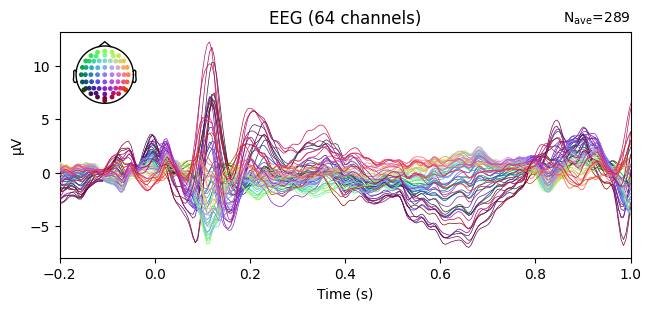

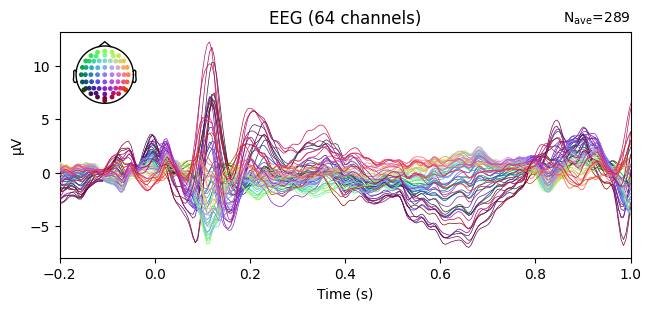

In [569]:
evoked=clean[6].average()
evoked.plot()

In [7]:
# Function to reject and interpolate bad epochs and save drop log to a CSV
def autoreject_epochs(subject, reref_path, clean_path, overwrite):
    """
    Apply AutoReject to clean epochs, save cleaned epochs, and export drop log to a CSV file.
    
    Parameters:
    - subject: str
        The subject identifier (e.g., 'subject01').
    - reref_path: str
        The path where the rereferenced epochs are stored.
    - clean_path: str
        The path where the cleaned epochs should be saved.
    - overwrite: bool
        Whether to overwrite the existing file.
    
    Returns:
    - epochs_clean: mne.Epochs
        The cleaned epochs object.
    """
    
    # Load epochs file
    ica_epochs = mne.read_epochs(reref_path + subject + 'apply_baseline' + '-epo.fif')
    
    # Apply AutoReject to the epochs
    ar = AutoReject()
    epochs_clean = ar.fit_transform(ica_epochs)
    
    # Save cleaned epochs
    clean_epochs_name = subject + 'ar' + '-epo.fif'
    ica_epochs_path = clean_path + clean_epochs_name
    epochs_clean.save(ica_epochs_path, overwrite=overwrite)

    # Extract the drop log from the cleaned epochs
    drop_log = epochs_clean.drop_log
    
    # Convert the drop log to a DataFrame for easier export to CSV
    drop_log_df = pd.DataFrame({
        'epoch': range(len(drop_log)),
        'drop_reason': [', '.join([reason for reason in log if reason]) if log else 'OK' for log in drop_log]
    })
    
    # Save the drop log as a CSV file
    drop_log_filename = clean_path + subject + '_drop_log.csv'
    drop_log_df.to_csv(drop_log_filename, index=False)
    
    print(f"Drop log saved as {drop_log_filename}")
    
    return epochs_clean


In [8]:
ar_epochs = [autoreject_epochs(subject, reref_path=baseline_corrected_path, clean_path=ar_epochs_path, overwrite=True) for subject in subs]

Reading /Users/jasongeller/Desktop/EEG_Codin/baseline_correct_epochs/1018-GZN0Kapply_baseline-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available
Not setting metadata
289 matching events found
No baseline correction applied
0 projection items activated
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/64 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/64 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/289 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/289 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.40 and n_interpolate=4


  0%|          | Repairing epochs : 0/289 [00:00<?,       ?it/s]

Dropped 25 epochs: 35, 38, 43, 44, 51, 52, 65, 67, 80, 90, 93, 94, 99, 101, 106, 107, 108, 111, 145, 164, 214, 246, 264, 277, 279
Overwriting existing file.
Overwriting existing file.
Drop log saved as /Users/jasongeller/Desktop/EEG_Codin/autoreject_epochs/1007-0I5L2_drop_log.csv


In [589]:

evoked_cong = ar_epochs[4]['congruent'].average()
evoked_incong =ar_epochs[4]['incongruent'].average()


['1018-GZN0K',
 '1016-U5RMG',
 '1030-HBQT4',
 '1017-ua5ro',
 '1029-N6INB',
 '1009-QKXGY',
 '1007-0I5L2']

# Evokeds

In [627]:
# Function 1: Compute and save individual evoked responses for a single subject
def compute_and_save_evokeds(cleaned_epochs_path, subject, evoked_path):
    # Generate a subject ID
    subject_id = subject

    # Read in cleaned epochs for the subject
    epochs_file = f"{cleaned_epochs_path}/{subject_id}ar-epo.fif"
    epochs = mne.read_epochs(epochs_file, preload=True)

    # Initialize lists to store evoked responses
    congruent_evoked_list = []
    incongruent_evoked_list = []
    
    # Process the 'congruent' condition
    if 'congruent' in epochs.event_id:
        congruent_evoked = epochs['congruent'].average()
        congruent_evoked_list.append(congruent_evoked)

        # Save evoked to a .fif file
        congruent_evoked.save(f'{evoked_path}/{subject_id}_congruent-ave.fif')

        # Convert the evoked data to a DataFrame
        df_congruent = pd.DataFrame({
            'subject': subject_id,
            'time': congruent_evoked.times,
            'evoked': congruent_evoked.data.mean(axis=0),  # Average across channels
            'condition': 'congruent'
        })
        # Save evoked data to CSV
        df_congruent.to_csv(f'{evoked_path}/{subject_id}_congruent_evoked.csv', index=False)

    # Process the 'incongruent' condition
    if 'incongruent' in epochs.event_id:
        incongruent_evoked = epochs['incongruent'].average()
        incongruent_evoked_list.append(incongruent_evoked)

        # Save evoked to a .fif file
        incongruent_evoked.save(f'{evoked_path}/{subject_id}_incongruent-ave.fif')

        # Convert the evoked data to a DataFrame
        df_incongruent = pd.DataFrame({
            'subject': subject_id,
            'time': incongruent_evoked.times,
            'evoked': incongruent_evoked.data.mean(axis=0),  # Average across channels
            'condition': 'incongruent'
        })
        # Save evoked data to CSV
        df_incongruent.to_csv(f'{evoked_path}/{subject_id}_incongruent_evoked.csv', index=False)

    # Return the individual evoked responses for the subject
    return congruent_evoked_list, incongruent_evoked_list

In [632]:
evoked_data = [compute_and_save_evokeds(cleaned_epochs_path=ar_epochs_path, subject=subject, evoked_path=evoked_path) for subject in subs]

Reading /Users/jasongeller/Desktop/EEG_Codin/autoreject_epochs/1018-GZN0Kar-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Reading /Users/jasongeller/Desktop/EEG_Codin/autoreject_epochs/1016-U5RMGar-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available
Not setting metadata
289 matching events found
No baseline correction applied
0 projection items activated
Reading /Users/jasongeller/Desktop/EEG_Codin/autoreject_epochs/1030-HBQT4ar-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available
Not setting metadata
260 matching events found
No baseline correction applied
0 projection items activated
Reading /Users/jasongeller/Desktop/EEG_Codin/autoreject_ep

# Grand Average

In [653]:
def read_evokeds_and_compute_grand_average(evoked_path, grand_path, subjects, roi, overwrite=True):
    congruent_evoked_list = []
    incongruent_evoked_list = []
    
    # Iterate over each subject to load their evoked responses
    for subject_id in subjects:
        # Load evoked responses from .fif files for congruent and incongruent conditions
        congruent_evoked = mne.read_evokeds(f'{evoked_path}/{subject_id}_congruent-ave.fif')[0]
        incongruent_evoked = mne.read_evokeds(f'{evoked_path}/{subject_id}_incongruent-ave.fif')[0]
        
        # Append the evoked responses to their respective lists
        congruent_evoked_list.append(congruent_evoked)
        incongruent_evoked_list.append(incongruent_evoked)

    # Compute grand average for each condition
    grand_average_congruent = mne.grand_average(congruent_evoked_list)
    grand_average_incongruent = mne.grand_average(incongruent_evoked_list)

    # Define the file paths
    congruent_fif = f'{grand_path}/grand_average_congruent-ave.fif'
    incongruent_fif = f'{grand_path}/grand_average_incongruent-ave.fif'
    comparison_plot_path = f'{grand_path}/grand_average_comparison_plot.png'
    combined_csv_path = f'{grand_path}/grand_average_combined.csv'

    # Overwrite existing files if necessary
    if overwrite:
        if os.path.exists(congruent_fif):
            os.remove(congruent_fif)
        if os.path.exists(incongruent_fif):
            os.remove(incongruent_fif)
        if os.path.exists(comparison_plot_path):
            os.remove(comparison_plot_path)
        if os.path.exists(combined_csv_path):
            os.remove(combined_csv_path)

    # Save grand average evoked responses to .fif files
    grand_average_congruent.save(congruent_fif)
    grand_average_incongruent.save(incongruent_fif)

    # Create a dictionary to pass the grand averages with condition names for labeling
    evokeds = {
        'Congruent': grand_average_congruent,
        'Incongruent': grand_average_incongruent
    }

    # Plot the evoked responses for comparison
    fig, ax = plt.subplots(figsize=(10, 6))
    mne.viz.plot_compare_evokeds(evokeds, picks=roi, combine="mean",
                                 title='P600 Comparison at Central-Parietal Electrodes ID',
                                 axes=ax, legend=True, vlines=[0.5, 0.7])
    
    # Save the comparison plot
    plt.savefig(comparison_plot_path)

    # Combine grand average congruent and incongruent into one DataFrame
    df_grand_congruent = pd.DataFrame({
        'subject': 'grand_average',
        'time': grand_average_congruent.times,
        'evoked': grand_average_congruent.data.mean(axis=0),  # Average across channels
        'condition': 'congruent'
    })

    df_grand_incongruent = pd.DataFrame({
        'subject': 'grand_average',
        'time': grand_average_incongruent.times,
        'evoked': grand_average_incongruent.data.mean(axis=0),  # Average across channels
        'condition': 'incongruent'
    })

    # Combine and save grand average to a single CSV
    df_grand_combined = pd.concat([df_grand_congruent, df_grand_incongruent])
    df_grand_combined.to_csv(combined_csv_path, index=False)

    print(f"Grand averages saved in {grand_path}")
    
    # Return the figure for display or further use
    return fig

Reading /Users/jasongeller/Desktop/EEG_Codin/Evokeds/1018-GZN0K_congruent-ave.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms (congruent)
        0 CTF compensation matrices available
        nave = 217 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.2, 0] s)
Reading /Users/jasongeller/Desktop/EEG_Codin/Evokeds/1018-GZN0K_incongruent-ave.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms (incongruent)
        0 CTF compensation matrices available
        nave = 71 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.2, 0] s)
Reading /Users/jasongeller/Desktop/EEG_Codin/Evokeds/1016-U5RMG_congruent-ave.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms (congruent)
        0 CTF comp

<Figure size 640x480 with 0 Axes>

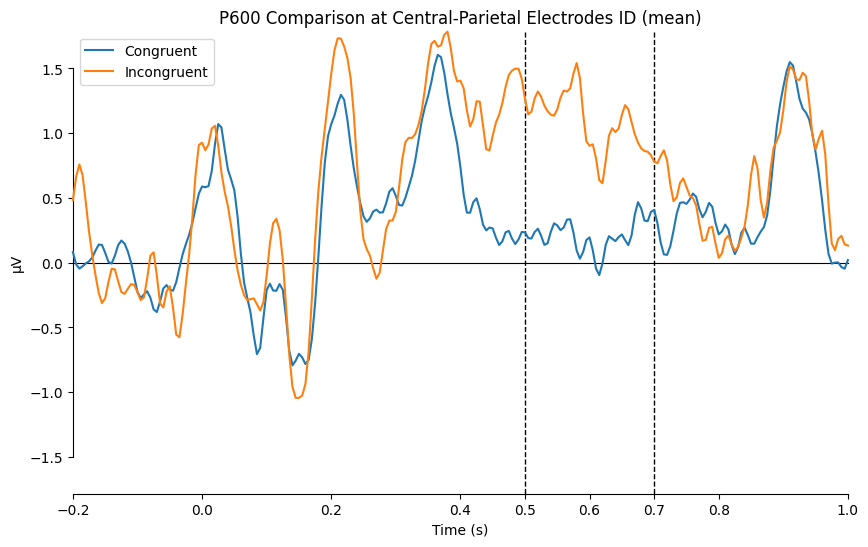

Grand averages saved in /Users/jasongeller/Desktop/EEG_Codin/Grand_average


In [654]:
# Define your region of interest (ROI), e.g., central-parietal electrodes
# Define the region of interest (ROI) channels
roi = ['Cz', 'Pz', 'CPz', 'C3', 'C4', 'P3', 'P4']

# Read evokeds, compute grand average, and plot
fig = read_evokeds_and_compute_grand_average(evoked_path=evoked_path, grand_path=grand_path, subjects=subs, roi=roi, overwrite=True)
